C:\Users\varad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\varad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\varad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\varad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

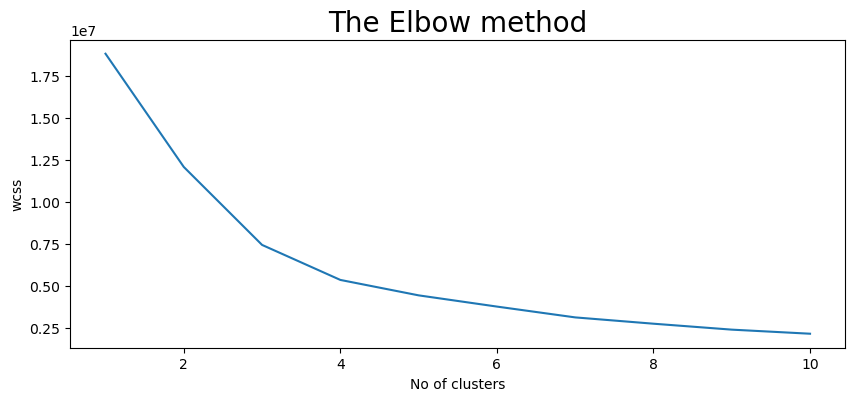

lets check the results after applying the K-Means clustering analysis 

Crops in First cluster: ['grapes' 'apple']
_____________________________________________________________________

Crops in Second cluster: ['maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans' 'mungbean'
 'blackgram' 'lentil' 'pomegranate' 'mango' 'orange' 'papaya' 'coconut']
_____________________________________________________________________

Crops in Third cluster: ['maize' 'banana' 'watermelon' 'muskmelon' 'papaya' 'cotton' 'coffee']
_____________________________________________________________________

Crops in Fourth cluster: ['rice' 'pigeonpeas' 'papaya' 'coconut' 'jute' 'coffee']


C:\Users\varad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


In [5]:
# ==========================================
# CELL 1: K-MEANS CLUSTERING & ELBOW METHOD
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load your dataset
df = pd.read_csv('Crop_recommendation.csv')

# The workspace uses the numerical columns for clustering
x = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']].values

# 1. Generating the Elbow Graph
plt.rcParams['figure.figsize'] = (10, 4)
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init="k-means++", max_iter=300, n_init=10, random_state=0)
    km.fit(x)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("The Elbow method", fontsize=20)
plt.xlabel("No of clusters")
plt.ylabel("wcss")
plt.show()

# 2. Applying K-Means with the optimal 4 clusters
km = KMeans(n_clusters=4, init="k-means++", max_iter=300, n_init=10, random_state=0)
y_means = km.fit_predict(x)

# 3. Organizing results to print unique crops per cluster group
a = df['label']
y_means = pd.DataFrame(y_means)
z = pd.concat([y_means, a], axis=1)
z = z.rename(columns={0: 'cluster'})

print("lets check the results after applying the K-Means clustering analysis \n")
print("Crops in First cluster:", z[z['cluster']==0]['label'].unique())
print("_____________________________________________________________________\n")
print("Crops in Second cluster:", z[z['cluster']==1]['label'].unique())
print("_____________________________________________________________________\n")
print("Crops in Third cluster:", z[z['cluster']==2]['label'].unique())
print("_____________________________________________________________________\n")
print("Crops in Fourth cluster:", z[z['cluster']==3]['label'].unique())

In [6]:
# ==========================================
# CELL 2: LOGISTIC REGRESSION TRAINING
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Splitting our features for the classification task
X_train, X_test, y_train, y_test = train_test_split(
    df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']], 
    df['label'], 
    test_size=0.2, 
    random_state=42
)

# Initialize and fit the Logistic Regression classifier
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Logistic Regression model successfully trained using fit() method!")

Logistic Regression model successfully trained using fit() method!


C:\Users\varad\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
# ==========================================
# CELL 3: EVALUATING PERFORMANCE & SAVING
# ==========================================
from sklearn.metrics import classification_report
import pickle

print("Checking model performance:")
cr = classification_report(y_test, y_pred)
print(cr)

# Serialize and save the model file matching your platform requirement exactly
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("\nModel successfully serialized and stored as 'model.pkl'!")

Checking model performance:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.85      0.85      0.85        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.89      0.94      0.91        17
      grapes       1.00      1.00      1.00        14
        jute       0.87      0.87      0.87        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.83      0.91      0.87        11
       maize       0.95      0.90      0.93        21
       mango       1.00      1.00      1.00        19
   mothbeans       0.92      0.96      0.94        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14

In [8]:
# ==========================================
# CELL 4: PREDICT BEST CROP FOR USER INPUT
# ==========================================
import numpy as np

# Real field data testing array example from your dashboard template
prediction = model.predict(np.array([[90, 42, 43, 20.87, 82.00, 6.50, 202.93]]))

print(f"The suggested crop for given climatic condition is: {prediction}")

The suggested crop for given climatic condition is: ['rice']


C:\Users\varad\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
!python app.py